In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
%matplotlib widget

# Generating Energy spectrum, Wavefunctions and Pfaffian invariant for 1D SMSC Nanowire
We consider the following Hamiltonian to study the behavior of microscopic capacitance and impedance calculations,

$$
\begin{align}
&\mathcal{H}_{SM} = \sum_{i,\sigma} \left[-t(c^\dagger_{i\sigma}c_{i+1\sigma}+\text{h.c.}) + (V_{dis}(i)-\mu)c^\dagger_{i\sigma}c_{i\sigma}\right] +\frac{\alpha}{2}\sum_i\left[(c^\dagger_{i\uparrow}c_{i+1\downarrow} - c^\dagger_{i\downarrow}c_{i+1\uparrow}) + \text{h.c.}\right]+\sum_i(c^\dagger_{i\uparrow}c_{i\downarrow} + \text{h.c.}) \\
&\mathcal{H}_{eff} = \mathbb{Z}\cdot\mathcal{H}_{SM} + \mathbb{I}\cdot\Delta\sigma_y\tau_y
\end{align} 
$$

where $\mathbb{Z} = \Delta_0/(\Delta_0 + \gamma)$ is the quasiparticle residue and $\Delta = \Delta_0\gamma/(\Delta_0 + \gamma)$ is the induced superconducting pairing potential. The quantum dot (QD) coupling has the following form,

$$
\mathcal{H}_{QD} = \sum_{\sigma}(V_{QD}-\mu)a^\dagger_{\sigma}a_{\sigma} + \sum_{\sigma}\left[\lambda_Re^{i\phi}\left(-tc^\dagger_{0\sigma}a_\sigma - \frac{\alpha}{2}c^\dagger_{0\uparrow}a_\downarrow + \text{h.c.}\right) + \lambda_L\left(-tc^\dagger_{N-1\sigma}a_\sigma + \frac{\alpha}{2}c^\dagger_{N-1\uparrow}a_\downarrow + \text{h.c.}\right)\right]
$$

where $a^\dagger_\sigma \equiv c^\dagger_{N\sigma} (a_\sigma \equiv c_{N\sigma})$ is the creation (annihilation) operator corresponding to the dot state $n_0$ with spin $\sigma$ and $\phi = \pi\Phi/\Phi_0$ with $\Phi_0 = h/2e$, is a flux-dependent phase.

In [ ]:
# Read in files
parameter_space = "mu_285_gam_076"
mu = 2.85
Ez = 0.76
vqd_low = 2.84
vqd_high = 2.92
vqd_loc = 2.9
## Files with QD
Energy_spectra_w_QD = np.loadtxt(open("Energy_spectra_w_QD_"+parameter_space+".txt","rb"))
E_v_phi_w_QD = np.loadtxt(open("E_vs_phi_w_QD_"+parameter_space+".txt","rb"))
pfaf_1d_w_QD = np.loadtxt(open("Pfafian_spectra_w_QD_"+parameter_space+".txt","rb"))
mf_wf1_w_QD = np.loadtxt(open("Wavefunction_1_w_QD_"+parameter_space+".txt","rb"))
mf_wf2_w_QD = np.loadtxt(open("Wavefunction_2_w_QD_"+parameter_space+".txt","rb"))
### Files without QD
Energy_spectra_wo_QD = np.loadtxt(open("Energy_spectra_wo_QD_"+parameter_space+".txt","rb"))
E_v_phi_wo_QD = np.loadtxt(open("E_vs_phi_wo_QD_"+parameter_space+".txt","rb"))
pfaf_1d_wo_QD = np.loadtxt(open("Pfafian_spectra_wo_QD_"+parameter_space+".txt","rb"))
mf_wf1_wo_QD = np.loadtxt(open("Wavefunction_1_wo_QD_"+parameter_space+".txt","rb"))
mf_wf2_wo_QD = np.loadtxt(open("Wavefunction_2_wo_QD_"+parameter_space+".txt","rb"))
#### Common files
C_vs_phi_even = np.loadtxt(open("Capacitance_even_"+parameter_space+".txt","rb"))
C_vs_phi_odd = np.loadtxt(open("Capacitance_odd_"+parameter_space+".txt","rb"))
C_vs_VQD_phi_0 = np.loadtxt(open("Capacitance_v_VQD_phi_0_"+parameter_space+".txt","rb"))
C_vs_VQD_phi_pi = np.loadtxt(open("Capacitance_v_VQD_phi_pi_"+parameter_space+".txt","rb"))
L_vs_phi_even_D = np.loadtxt(open("Impedance_even_D_"+parameter_space+".txt","rb"))
L_vs_phi_even_P = np.loadtxt(open("Impedance_even_P_"+parameter_space+".txt","rb"))
L_vs_phi_odd_D = np.loadtxt(open("Impedance_odd_D_"+parameter_space+".txt","rb"))
L_vs_phi_odd_P = np.loadtxt(open("Impedance_odd_P_"+parameter_space+".txt","rb"))
L_vs_VQD_phi_D_0 = np.loadtxt(open("Impedance_v_VQD_phi_0_D_"+parameter_space+".txt","rb"))
L_vs_VQD_phi_P_0 = np.loadtxt(open("Impedance_v_VQD_phi_0_P_"+parameter_space+".txt","rb"))
L_vs_VQD_phi_D_pi = np.loadtxt(open("Impedance_v_VQD_phi_pi_D_"+parameter_space+".txt","rb"))
L_vs_VQD_phi_P_pi = np.loadtxt(open("Impedance_v_VQD_phi_pi_P_"+parameter_space+".txt","rb"))

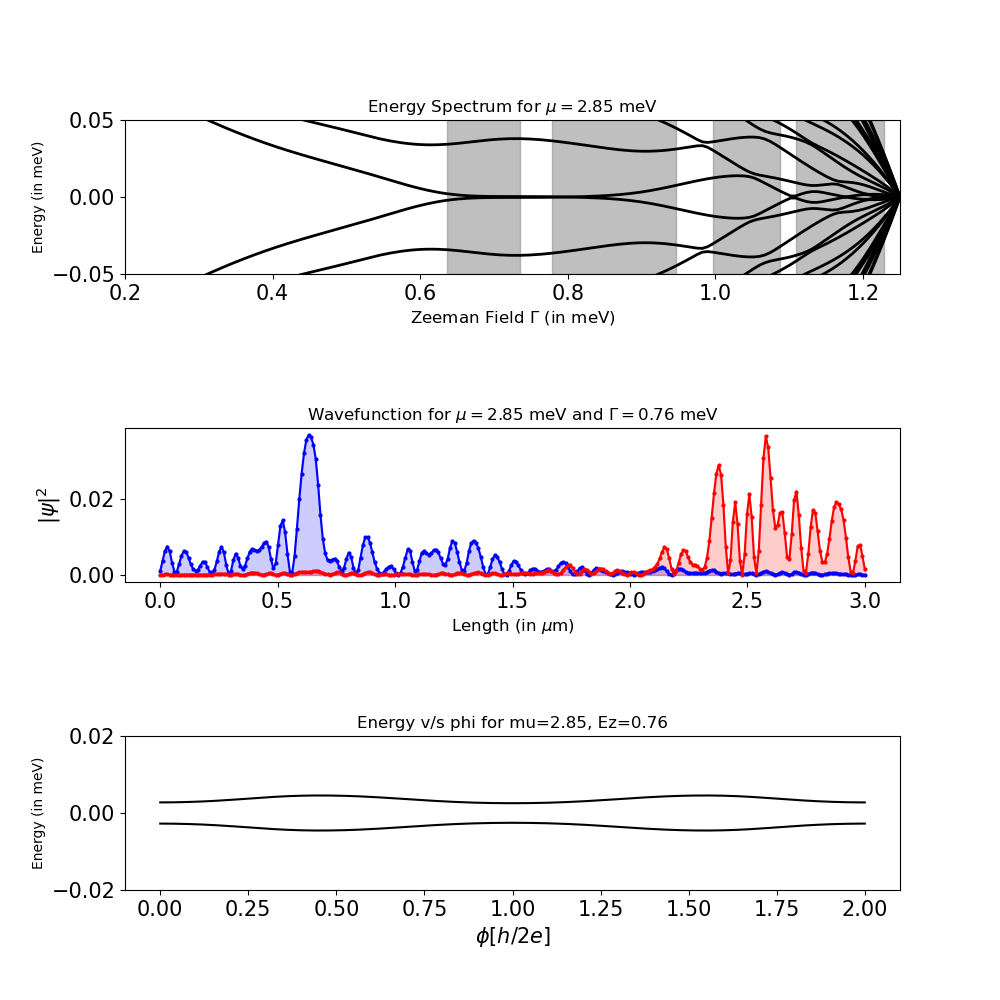

In [4]:
## Plotting all the Spectral properties without QD

fig = plt.figure(figsize=(10, 10))
gs = GridSpec(3,1, figure=fig, hspace=1.)

ax1_woQD = fig.add_subplot(gs[0,0])
for i in range(len(Energy_spectra_wo_QD[0])):
        ax1_woQD.plot(np.linspace(0.2,1.25,150), Energy_spectra_wo_QD[:, i], "k", lw=2.0)
ax1_woQD.set_ylim(-0.05,0.05)
ax1_woQD.fill_between(np.linspace(0.2,1.25,150), -0.05, 0.05, where=(pfaf_1d_wo_QD<0.0), color='gray', alpha=0.5)
ax1_woQD.tick_params(axis='both', which='major', labelsize=15)
ax1_woQD.set_ylabel("Energy (in meV)")
ax1_woQD.set_xlabel(r"Zeeman Field $\Gamma$ (in meV)", fontsize=12)
ax1_woQD.set_xlim(0.2,1.25)
ax1_woQD.set_title(r"Energy Spectrum for $\mu = $"+str(np.round(mu,2))+" meV")

wire_Length = 300
wire = lambda L: np.linspace(0.0,3.0,L)
ax2_woQD = fig.add_subplot(gs[1,0])
ax2_woQD.plot(wire(wire_Length), mf_wf1_wo_QD, 'o-', color='blue', markersize=2.0)
ax2_woQD.fill_between(wire(wire_Length), 0.0, mf_wf1_wo_QD, color='blue', alpha=0.2)
ax2_woQD.plot(wire(wire_Length), mf_wf2_wo_QD, 'o-', color='red', markersize=2.0)
ax2_woQD.fill_between(wire(wire_Length), 0.0, mf_wf2_wo_QD, color='red', alpha=0.2)
#ax2_woQD.set_ylim(0.0, 0.03)
ax2_woQD.tick_params(axis='both', which='major', labelsize=15)
ax2_woQD.set_ylabel(r"$\vert\psi\vert^2$", fontsize=15)
ax2_woQD.set_xlabel(r"Length (in $\mu$m)", fontsize=12)
ax2_woQD.set_title(r"Wavefunction for $\mu = $"+str(np.round(mu,2))+r" meV and $\Gamma = $"+str(np.round(Ez,2))+" meV")

angles = lambda a_N: np.linspace(0.0,2.0,a_N)
ax3_woQD = fig.add_subplot(gs[2,0])
for i in range(len(E_v_phi_wo_QD[0])):
        ax3_woQD.plot(angles(150), E_v_phi_wo_QD[:, i], "k", lw=1.5)
ax3_woQD.set_ylim(-0.02,0.02)
ax3_woQD.tick_params(axis='both', which='major', labelsize=15)
ax3_woQD.set_ylabel(r"Energy (in meV)")
ax3_woQD.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax3_woQD.set_title(f"Energy v/s phi for mu={mu}, Ez={Ez}")

plt.show()

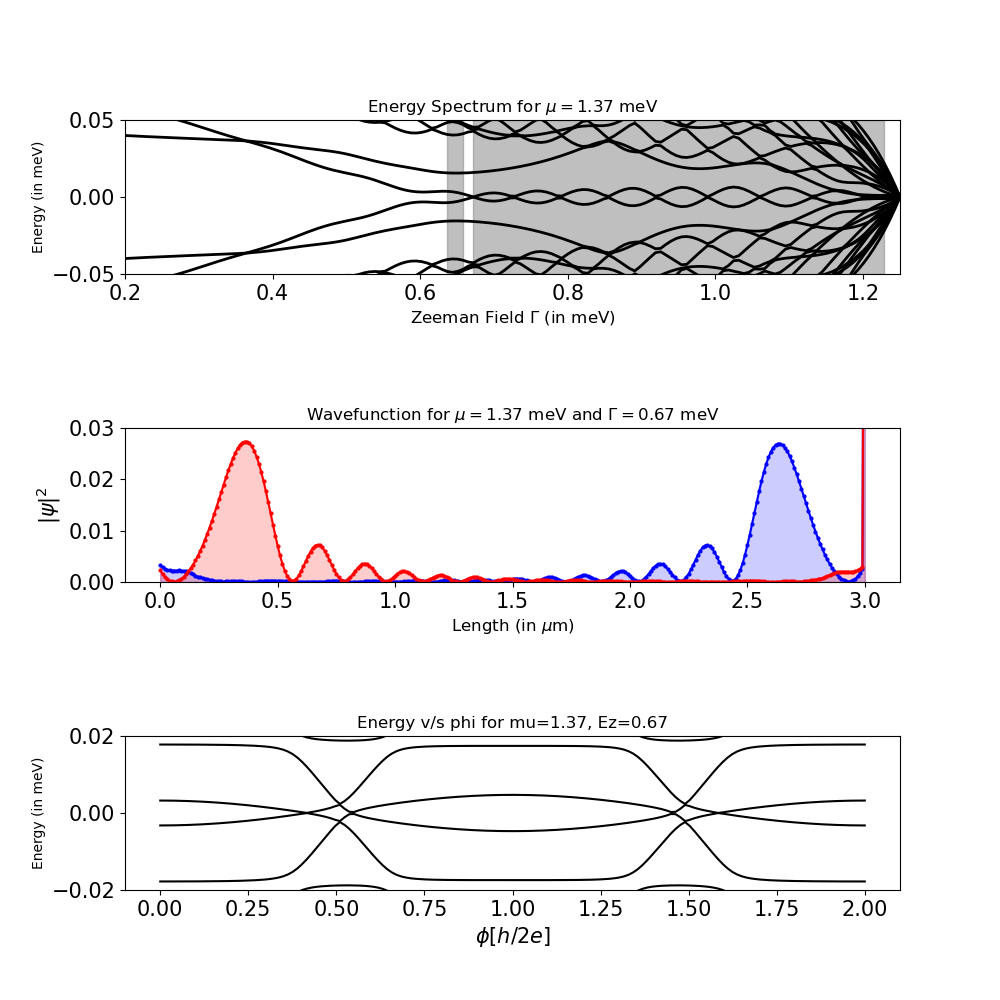

In [ ]:
## Plotting all the Spectral properties with QD

fig = plt.figure(figsize=(10, 10))
gs = GridSpec(3,1, figure=fig, hspace=1.)

ax1_wQD = fig.add_subplot(gs[0,0])
for i in range(len(Energy_spectra_w_QD[0])):
        ax1_wQD.plot(np.linspace(0.2,1.25,150), Energy_spectra_w_QD[:, i], "k", lw=2.0)
ax1_wQD.set_ylim(-0.05,0.05)
ax1_wQD.fill_between(np.linspace(0.2,1.25,150), -0.05, 0.05, where=(pfaf_1d_w_QD<0.0), color='gray', alpha=0.5)
ax1_wQD.tick_params(axis='both', which='major', labelsize=15)
ax1_wQD.set_ylabel("Energy (in meV)")
ax1_wQD.set_xlabel(r"Zeeman Field $\Gamma$ (in meV)", fontsize=12)
ax1_wQD.set_xlim(0.2,1.25)
ax1_wQD.set_title(r"Energy Spectrum for $\mu = $"+str(np.round(mu,2))+" meV")

wire_Length = 300
wire = lambda L: np.linspace(0.0,3.0,L)
ax2_wQD = fig.add_subplot(gs[1,0])
ax2_wQD.plot(wire(wire_Length+1), mf_wf1_w_QD, 'o-', color='blue', markersize=2.0)
ax2_wQD.fill_between(wire(wire_Length+1), 0.0, mf_wf1_w_QD, color='blue', alpha=0.2)
ax2_wQD.plot(wire(wire_Length+1), mf_wf2_w_QD, 'o-', color='red', markersize=2.0)
ax2_wQD.fill_between(wire(wire_Length+1), 0.0, mf_wf2_w_QD, color='red', alpha=0.2)
#ax2_wQD.set_ylim(0.0, 0.03)
ax2_wQD.tick_params(axis='both', which='major', labelsize=15)
ax2_wQD.set_ylabel(r"$\vert\psi\vert^2$", fontsize=15)
ax2_wQD.set_xlabel(r"Length (in $\mu$m)", fontsize=12)
ax2_wQD.set_title(r"Wavefunction for $\mu = $"+str(np.round(mu,2))+r" meV and $\Gamma = $"+str(np.round(Ez,2))+" meV")

angles = lambda a_N: np.linspace(0.0,2.0,a_N)
ax3_wQD = fig.add_subplot(gs[2,0])
for i in range(len(E_v_phi_w_QD[0])):
        ax3_wQD.plot(angles(150), E_v_phi_w_QD[:, i], "k", lw=1.5)
ax3_wQD.set_ylim(-0.02,0.02)
ax3_wQD.tick_params(axis='both', which='major', labelsize=15)
ax3_wQD.set_ylabel(r"Energy (in meV)")
ax3_wQD.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax3_wQD.set_title(f"Energy v/s phi for mu={mu}, Ez={Ez}")

plt.show()

# Capacitance and Impedance Formulas

The formula we use to calculate the capacitance and impedance values for this finite disordered nanowire system in terms of the eigenstates and energy eigenvalues is given in the Lehmann representation as,

$$
\begin{align}
&\mathcal{C}(\phi,\omega) = \kappa_C\sum_{n,m}\frac{\vert{\bra{n}{\partial_{V_{QD}} H}\ket{m}}\vert^2 (E_n - E_m)}{(E_n - E_m)^2 - (\omega + i\eta)^2} \\
&\mathcal{L}^{-1}(\phi,\omega) = \kappa_L\left[\sum_n\bra{n}\partial^2_{\phi} H\ket{n}-2\sum_{n,m}\frac{\vert{\bra{n}{\partial_{\phi} H}\ket{m}}\vert^2 (E_n - E_m)}{(E_n - E_m)^2 - (\omega + i\eta)^2}\right]
\end{align}
$$
where $\kappa_C = 0.032 fF \cdot meV$ and $\kappa_L = 1.48 nH^{-1}\cdot meV$.

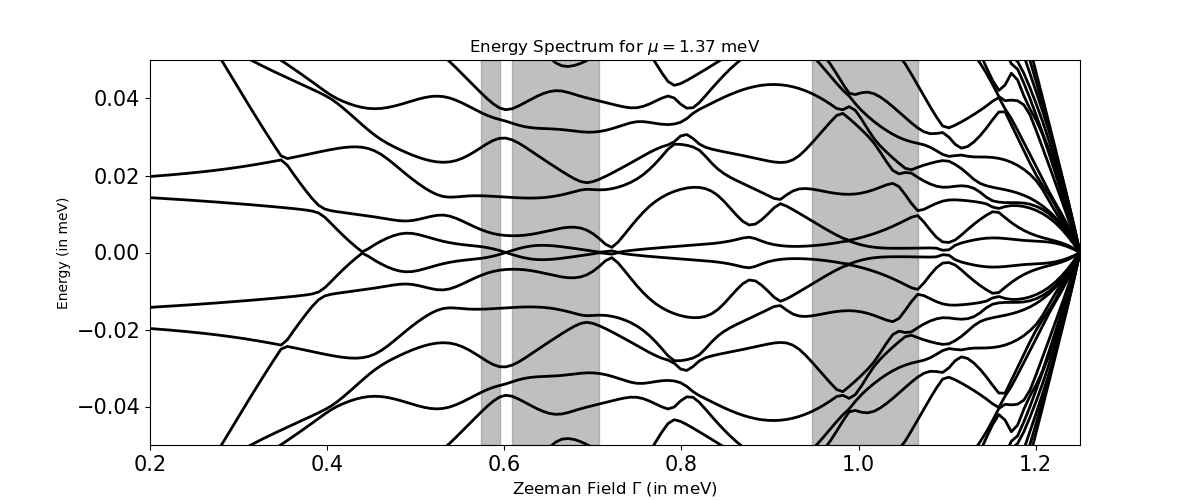

In [ ]:
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4,1, figure=fig, hspace=1.)

ax1_C = fig.add_subplot(gs[0,0])
ax1_C.plot(angles, C_vs_VQD_phi_0, '-o', label='Even', markersize=2.0)
ax1_C.plot(angles, C_vs_VQD_phi_pi, '-o', label='Odd', markersize=2.0)
ax1_C.tick_params(axis='both', which='major', labelsize=15)
ax1_C.set_title(r"Capacitance v/s phi for $V_{QD}$= "+str(np.round(vqd_loc,2))+"meV")
ax1_C.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax1_C.set_ylabel(r'$C$', fontsize=15)
ax1_C.legend()

ax2_L_P = fig.add_subplot(gs[1,0])
ax2_L_P.plot(angles, L_vs_VQD_phi_P_0, '-o', label='Even', markersize=2.0)
ax2_L_P.plot(angles, L_vs_VQD_phi_P_pi, '-o', label='Odd', markersize=2.0)
ax2_L_P.tick_params(axis='both', which='major', labelsize=15)
ax2_L_P.set_title(r"Impedance v/s phi for $V_{QD}$= "+str(np.round(vqd_loc,2))+"meV")
ax2_L_P.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax2_L_P.set_ylabel(r'$L^{-1}$', fontsize=15)
ax2_L_P.legend()

ax3_L_D = fig.add_subplot(gs[2,0])
ax3_L_D.plot(angles, L_vs_VQD_phi_D_0, '-o', label='Even', markersize=2.0)
ax3_L_D.plot(angles, L_vs_VQD_phi_D_pi, '-o', label='Odd', markersize=2.0)
ax3_L_D.tick_params(axis='both', which='major', labelsize=15)
ax3_L_D.set_title(r"Impedance v/s phi for $V_{QD}$= "+str(np.round(vqd_loc,2))+"meV")
ax3_L_D.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax3_L_D.set_ylabel(r'$L^{-1}$', fontsize=15)
ax3_L_D.legend()

ax4_L = fig.add_subplot(gs[3,0])
ax4_L.plot(angles, L_vs_VQD_phi_D_0+L_vs_VQD_phi_P_0, '-o', label='Even', markersize=2.0)
ax4_L.plot(angles, L_vs_VQD_phi_D_pi+L_vs_VQD_phi_P_pi, '-o', label='Odd', markersize=2.0)
ax4_L.tick_params(axis='both', which='major', labelsize=15)
ax4_L.set_title(r"Impedance v/s phi for $V_{QD}$= "+str(np.round(vqd_loc,2))+"meV")
ax4_L.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax4_L.set_ylabel(r'$L^{-1}$', fontsize=15)
ax4_L.legend()


In [ ]:
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4,1, figure=fig, hspace=1.)

ax1_C = fig.add_subplot(gs[0,0])
ax1_C.plot(angles, C_vs_phi_even, '-o', label='Even', markersize=2.0)
ax1_C.plot(angles, C_vs_phi_odd, '-o', label='Odd', markersize=2.0)
ax1_C.tick_params(axis='both', which='major', labelsize=15)
ax1_C.set_title(r"Capacitance v/s phi for $V_{QD}$= "+str(np.round(vqd_loc,2))+"meV")
ax1_C.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax1_C.set_ylabel(r'$C$', fontsize=15)
ax1_C.legend()

ax2_L_P = fig.add_subplot(gs[1,0])
ax2_L_P.plot(angles, L_vs_phi_even_P, '-o', label='Even', markersize=2.0)
ax2_L_P.plot(angles, L_vs_phi_odd_P, '-o', label='Odd', markersize=2.0)
ax2_L_P.tick_params(axis='both', which='major', labelsize=15)
ax2_L_P.set_title(r"Impedance v/s phi for $V_{QD}$= "+str(np.round(vqd_loc,2))+"meV")
ax2_L_P.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax2_L_P.set_ylabel(r'$L^{-1}$', fontsize=15)
ax2_L_P.legend()

ax3_L_D = fig.add_subplot(gs[2,0])
ax3_L_D.plot(angles, L_vs_phi_even_D, '-o', label='Even', markersize=2.0)
ax3_L_D.plot(angles, L_vs_phi_odd_D, '-o', label='Odd', markersize=2.0)
ax3_L_D.tick_params(axis='both', which='major', labelsize=15)
ax3_L_D.set_title(r"Impedance v/s phi for $V_{QD}$= "+str(np.round(vqd_loc,2))+"meV")
ax3_L_D.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax3_L_D.set_ylabel(r'$L^{-1}$', fontsize=15)
ax3_L_D.legend()

ax4_L = fig.add_subplot(gs[3,0])
ax4_L.plot(angles, L_vs_phi_even_D+L_vs_phi_even_P, '-o', label='Even', markersize=2.0)
ax4_L.plot(angles, L_vs_phi_odd_D+L_vs_phi_odd_P, '-o', label='Odd', markersize=2.0)
ax4_L.tick_params(axis='both', which='major', labelsize=15)
ax4_L.set_title(r"Impedance v/s phi for $V_{QD}$= "+str(np.round(vqd_loc,2))+"meV")
ax4_L.set_xlabel(r'$\phi [h/2e]$', fontsize=15)
ax4_L.set_ylabel(r'$L^{-1}$', fontsize=15)
ax4_L.legend()
